# Substructure-Based Embedding Geometry — TEST_ISAB3

Examines how learned representations relate to molecular substructure using
RDKit fingerprints and functional group annotations from MassSpecGym SMILES.

Analyses:
1. Morgan fingerprint retrieval (Tanimoto kNN in fingerprint space vs embedding space)
2. MACCS keys / functional group enrichment in embedding neighborhoods
3. Fingerprint-conditioned UMAP coloring
4. Linear probe: fingerprint prediction from embeddings
5. Embedding similarity vs molecular similarity (Tanimoto) correlation

In [1]:
import os
import sys

os.chdir(os.path.join(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()))
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("Working directory:", os.getcwd())

Working directory: /home/wuhao/spectra-learning


In [2]:
CHECKPOINT_DIR = "experiments/TEST_ISAB3/trial_000"
CONFIG_PATH = "configs/gems_a_50_mask.py"
DEVICE = "cuda"

RANDOM_SEED = 42
UMAP_MAX_SAMPLES = 30_000
UMAP_NEIGHBORS = 30
UMAP_MIN_DIST = 0.3

In [3]:
import csv
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize as l2_normalize
from tqdm.auto import tqdm
import umap

from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors, rdMolDescriptors
from rdkit import DataStructs

from utils.training import load_config, build_model_from_config, load_pretrained_weights, latest_ckpt_path
from input_pipeline import (
    TfLightningDataModule,
    _MASSSPEC_HF_REPO,
    _MASSSPEC_TSV_PATH,
    _download_hf_file,
    numpy_batch_to_torch,
)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-02-19 06:32:04.531290: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-19 06:32:04.563245: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-02-19 06:32:05.486072: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Load Model & Extract Embeddings with SMILES

In [4]:
config = load_config(CONFIG_PATH)
datamodule = TfLightningDataModule(config, seed=int(config.seed))
config.num_peaks = datamodule.info["num_peaks"]
config.fingerprint_bits = int(datamodule.info["fingerprint_bits"])

backbone = build_model_from_config(config)
ckpt_path = latest_ckpt_path(Path(CHECKPOINT_DIR))
print(f"Loading checkpoint: {ckpt_path}")
load_pretrained_weights(backbone, ckpt_path)

device = torch.device(DEVICE if torch.cuda.is_available() else "cpu")
backbone = backbone.to(device)
backbone.eval()
for p in backbone.parameters():
    p.requires_grad = False

print(f"Model on {device}, params={sum(p.numel() for p in backbone.parameters()):,}")

INFO:input_pipeline:Found existing TFRecords at /home/wuhao/spectra-learning/data/gems_peaklist_tfrecord


Loading checkpoint: experiments/TEST_ISAB3/trial_000/checkpoints/step-00100000.pt


Model on cuda, params=19,842,432


In [5]:
# Read SMILES from TSV for massspec_train split (same order as TFRecords)
max_precursor_mz = float(config.get("max_precursor_mz", 1000.0))
tfrecord_dir = Path(config.get("tfrecord_dir", "data/gems_peaklist_tfrecord")).expanduser().resolve()
tsv_path = _download_hf_file(_MASSSPEC_HF_REPO, _MASSSPEC_TSV_PATH, tfrecord_dir.parent)

smiles_train = []
with Path(tsv_path).open() as f:
    reader = csv.DictReader(f, delimiter="\t")
    for row in reader:
        if row["fold"] == "train" and float(row["precursor_mz"]) <= max_precursor_mz:
            smiles_train.append(row["smiles"])

print(f"SMILES for massspec_train: {len(smiles_train):,}")

INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/roman-bushuiev/MassSpecGym/resolve/main/data/MassSpecGym.tsv "HTTP/1.1 302 Found"


SMILES for massspec_train: 194,119


In [6]:
# Extract embeddings from massspec_train using build_massspec_probe_dataset
# (includes fingerprints and uses deterministic ordering)
probe_peak_ordering = str(config.peak_ordering)
dataset = datamodule.build_massspec_probe_dataset(
    "massspec_train",
    seed=RANDOM_SEED,
    peak_ordering=probe_peak_ordering,
    shuffle=False,
    drop_remainder=False,
)

embed_list = []
fp_list = []
meta = {"adduct": [], "instrument": [], "precursor_mz": [], "n_valid_peaks": []}

smiles_idx = 0
print("Extracting embeddings...")
with torch.no_grad():
    for numpy_batch in tqdm(dataset.as_numpy_iterator()):
        batch = numpy_batch_to_torch(numpy_batch)
        batch_dev = {k: v.to(device) for k, v in batch.items()}

        embeddings = backbone.encoder(
            batch_dev["peak_mz"],
            batch_dev["peak_intensity"],
            valid_mask=batch_dev["peak_valid_mask"],
            precursor_mz=batch_dev.get("precursor_mz"),
        )
        pooled = backbone.pool(embeddings, batch_dev["peak_valid_mask"])

        embed_list.append(pooled.cpu().float())
        fp_list.append(batch["fingerprint"].numpy())
        meta["adduct"].append(batch["adduct_id"].to(torch.long))
        meta["instrument"].append(batch["instrument_type_id"].to(torch.long))
        meta["precursor_mz"].append(batch["precursor_mz"].to(torch.float32))
        meta["n_valid_peaks"].append(batch["peak_valid_mask"].sum(dim=1).to(torch.long))
        smiles_idx += batch["peak_mz"].shape[0]

all_embeds = torch.cat(embed_list, dim=0).numpy()
all_fps_morgan = np.concatenate(fp_list, axis=0)  # Morgan fingerprints from TFRecords
all_meta = {k: torch.cat(v).numpy() for k, v in meta.items()}
all_smiles = smiles_train[:len(all_embeds)]  # align

print(f"Embeddings: {all_embeds.shape}")
print(f"Morgan FPs: {all_fps_morgan.shape}")
print(f"SMILES: {len(all_smiles)}")
assert len(all_smiles) == len(all_embeds), f"Mismatch: {len(all_smiles)} vs {len(all_embeds)}"

Extracting embeddings...


0it [00:00, ?it/s]

2026-02-19 06:32:11.003569: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 250000


1it [00:01,  1.25s/it]

2it [00:01,  1.67it/s]

...

378it [00:54,  6.98it/s]

379it [00:55,  6.97it/s]

380it [00:55,  4.49it/s]

2026-02-19 06:33:06.486619: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
380it [00:55,  6.85it/s]

Embeddings: (194119, 256)
Morgan FPs: (194119, 1024)
SMILES: 194119


## 2. Compute RDKit Substructure Fingerprints & Functional Groups

In [7]:
# Compute MACCS keys and functional group counts from SMILES
n = len(all_smiles)
maccs_fps = np.zeros((n, 167), dtype=np.int8)

# Functional groups via SMARTS patterns
FG_SMARTS = {
    "hydroxyl": "[OX2H]",
    "carboxyl": "[CX3](=O)[OX2H1]",
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "amide": "[NX3][CX3](=[OX1])",
    "ester": "[#6][CX3](=O)[OX2H0][#6]",
    "ketone": "[#6][CX3](=O)[#6]",
    "aldehyde": "[CX3H1](=O)[#6]",
    "aromatic_ring": "c1ccccc1",
    "nitro": "[$([NX3](=O)=O),$([NX3+](=O)[O-])]",
    "sulfonyl": "[#16X4](=[OX1])(=[OX1])",
    "phosphate": "[PX4](=[OX1])([OX2])",
    "halide": "[F,Cl,Br,I]",
    "ether": "[OD2]([#6])[#6]",
    "thiol": "[#16X2H]",
    "nitrile": "[NX1]#[CX2]",
}
fg_patterns = {name: Chem.MolFromSmarts(sma) for name, sma in FG_SMARTS.items()}
fg_counts = {name: np.zeros(n, dtype=np.int16) for name in FG_SMARTS}

# Molecular descriptors
mol_weight = np.zeros(n, dtype=np.float32)
num_rings = np.zeros(n, dtype=np.int16)
num_aromatic_rings = np.zeros(n, dtype=np.int16)
num_heavy_atoms = np.zeros(n, dtype=np.int16)
logp = np.zeros(n, dtype=np.float32)

valid_mol_mask = np.ones(n, dtype=bool)

for i, smi in enumerate(tqdm(all_smiles, desc="Computing RDKit features")):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        valid_mol_mask[i] = False
        continue

    # MACCS keys
    maccs = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros(167, dtype=np.int8)
    DataStructs.ConvertToNumpyArray(maccs, arr)
    maccs_fps[i] = arr

    # Functional groups
    for name, pat in fg_patterns.items():
        fg_counts[name][i] = len(mol.GetSubstructMatches(pat))

    # Descriptors
    mol_weight[i] = Descriptors.ExactMolWt(mol)
    num_rings[i] = rdMolDescriptors.CalcNumRings(mol)
    num_aromatic_rings[i] = rdMolDescriptors.CalcNumAromaticRings(mol)
    num_heavy_atoms[i] = mol.GetNumHeavyAtoms()
    logp[i] = Descriptors.MolLogP(mol)

print(f"Valid molecules: {valid_mol_mask.sum():,} / {n:,}")
print(f"MACCS keys shape: {maccs_fps.shape}")
print(f"Functional groups: {list(FG_SMARTS.keys())}")

# Summary of functional group prevalence
print("\nFunctional group prevalence (fraction of molecules with >=1 occurrence):")
for name in FG_SMARTS:
    frac = (fg_counts[name][valid_mol_mask] > 0).mean()
    mean_count = fg_counts[name][valid_mol_mask].mean()
    print(f"  {name:20s}: {frac:.3f} (mean count={mean_count:.2f})")

Computing RDKit features:   0%|          | 0/194119 [00:00<?, ?it/s]

Computing RDKit features:   0%|          | 105/194119 [00:00<03:06, 1041.97it/s]

Computing RDKit features:   0%|          | 210/194119 [00:00<03:52, 832.90it/s] 

Computing RDKit features:   0%|          | 313/194119 [00:00<03:32, 910.73it/s]

Computing RDKit features:   0%|          | 407/194119 [00:00<03:37, 890.37it/s]

...

Computing RDKit features: 100%|█████████▉| 193895/194119 [02:47<00:00, 925.97it/s]

Computing RDKit features: 100%|█████████▉| 193988/194119 [02:47<00:00, 923.41it/s]

Computing RDKit features: 100%|█████████▉| 194082/194119 [02:47<00:00, 927.82it/s]

Computing RDKit features: 100%|██████████| 194119/194119 [02:47<00:00, 1157.89it/s]

Valid molecules: 194,119 / 194,119
MACCS keys shape: (194119, 167)
Functional groups: ['hydroxyl', 'carboxyl', 'amine', 'amide', 'ester', 'ketone', 'aldehyde', 'aromatic_ring', 'nitro', 'sulfonyl', 'phosphate', 'halide', 'ether', 'thiol', 'nitrile']

Functional group prevalence (fraction of molecules with >=1 occurrence):
  hydroxyl            : 0.555 (mean count=1.54)
  carboxyl            : 0.170 (mean count=0.19)
  amine               : 0.218 (mean count=0.28)
  amide               : 0.265 (mean count=0.37)
  ester               : 0.208 (mean count=0.30)
  ketone              : 0.121 (mean count=0.15)
  aldehyde            : 0.010 (mean count=0.01)
  aromatic_ring       : 0.641 (mean count=1.01)
  nitro               : 0.009 (mean count=0.01)
  sulfonyl            : 0.037 (mean count=0.04)
  phosphate           : 0.074 (mean count=0.17)
  halide              : 0.134 (mean count=0.22)
  ether               : 0.560 (mean count=1.25)
  thiol               : 0.002 (mean count=0.00)
  ni

## 3. Embedding Similarity vs Molecular (Tanimoto) Similarity

Pairs analyzed: 499,996
Cosine sim:  mean=0.0074, std=0.2589
Tanimoto:    mean=0.1080, std=0.0672

Pearson correlation (cosine_sim vs tanimoto): 0.0222


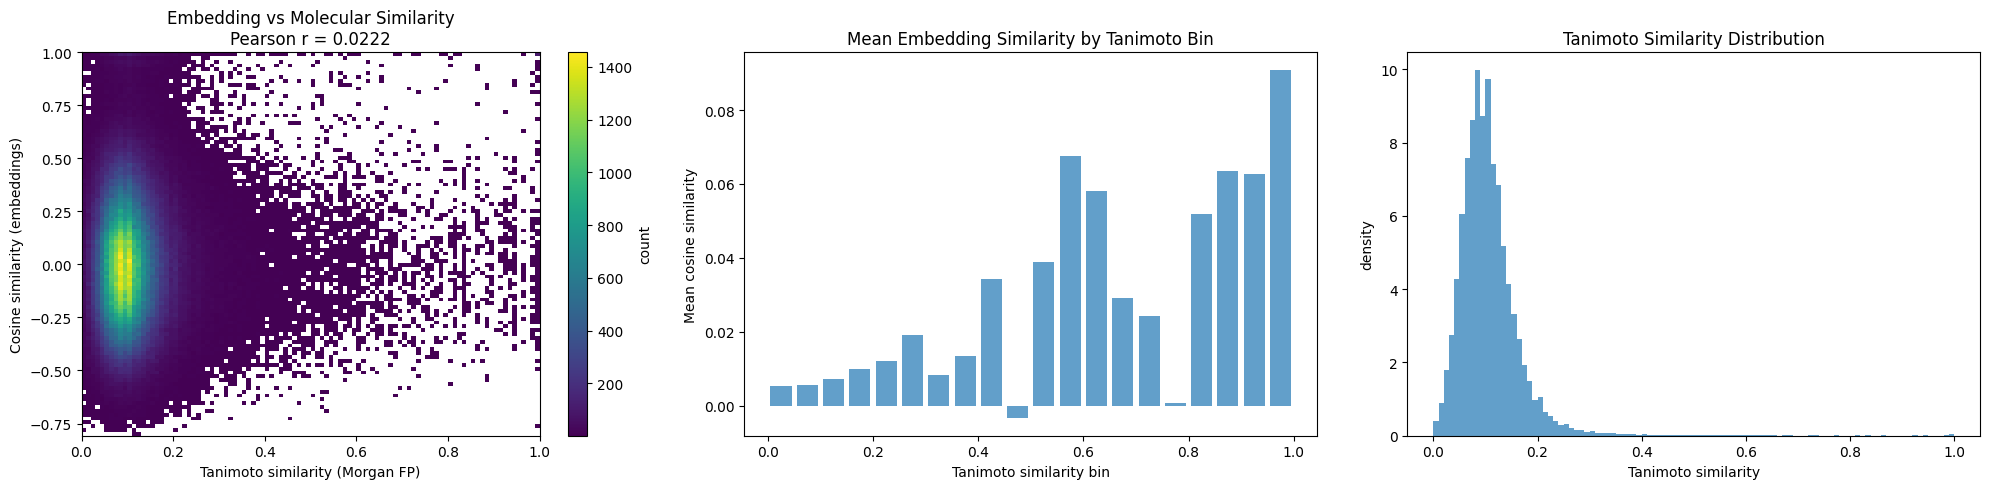

In [8]:
# Sample random pairs and compute cosine similarity (embedding) vs Tanimoto (Morgan FP)
rng = np.random.RandomState(RANDOM_SEED)
valid_idx = np.where(valid_mol_mask)[0]

n_pairs = 500_000
idx_a = rng.choice(valid_idx, size=n_pairs)
idx_b = rng.choice(valid_idx, size=n_pairs)
mask_diff = idx_a != idx_b
idx_a, idx_b = idx_a[mask_diff], idx_b[mask_diff]

# Cosine similarity in embedding space
embeds_normed = l2_normalize(all_embeds, axis=1)
cos_sims = (embeds_normed[idx_a] * embeds_normed[idx_b]).sum(axis=1)

# Tanimoto similarity from Morgan fingerprints
fp_a = all_fps_morgan[idx_a].astype(np.float32)
fp_b = all_fps_morgan[idx_b].astype(np.float32)
intersection = (fp_a * fp_b).sum(axis=1)
union = fp_a.sum(axis=1) + fp_b.sum(axis=1) - intersection
tanimoto = intersection / np.maximum(union, 1e-8)

print(f"Pairs analyzed: {len(idx_a):,}")
print(f"Cosine sim:  mean={cos_sims.mean():.4f}, std={cos_sims.std():.4f}")
print(f"Tanimoto:    mean={tanimoto.mean():.4f}, std={tanimoto.std():.4f}")

corr = float(np.corrcoef(cos_sims, tanimoto)[0, 1])
print(f"\nPearson correlation (cosine_sim vs tanimoto): {corr:.4f}")

# Bin Tanimoto and show mean cosine similarity per bin
bins = np.linspace(0, 1, 21)
bin_idx = np.digitize(tanimoto, bins) - 1
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_means = [cos_sims[bin_idx == i].mean() if (bin_idx == i).any() else np.nan for i in range(len(bin_centers))]
bin_counts = [(bin_idx == i).sum() for i in range(len(bin_centers))]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 2D histogram
axes[0].hist2d(tanimoto, cos_sims, bins=100, cmap="viridis", cmin=1)
axes[0].set_xlabel("Tanimoto similarity (Morgan FP)")
axes[0].set_ylabel("Cosine similarity (embeddings)")
axes[0].set_title(f"Embedding vs Molecular Similarity\nPearson r = {corr:.4f}")
plt.colorbar(axes[0].collections[0], ax=axes[0], label="count")

# Binned means
axes[1].bar(bin_centers, bin_means, width=0.04, alpha=0.7)
axes[1].set_xlabel("Tanimoto similarity bin")
axes[1].set_ylabel("Mean cosine similarity")
axes[1].set_title("Mean Embedding Similarity by Tanimoto Bin")

# Tanimoto distribution
axes[2].hist(tanimoto, bins=100, density=True, alpha=0.7, edgecolor="none")
axes[2].set_xlabel("Tanimoto similarity")
axes[2].set_ylabel("density")
axes[2].set_title("Tanimoto Similarity Distribution")

plt.tight_layout()
plt.show()

## 4. kNN Retrieval: Embedding Space vs Fingerprint Space

In [9]:
# For a subsample, find k-nearest neighbors in embedding space
# and measure Tanimoto similarity of those neighbors
subsample_size = min(20_000, valid_idx.shape[0])
sub_idx = rng.choice(valid_idx, size=subsample_size, replace=False)

sub_embeds = all_embeds[sub_idx]
sub_fps = all_fps_morgan[sub_idx].astype(np.float32)

K_VALUES = [1, 5, 10, 20, 50]

# kNN in embedding space (cosine)
knn_embed = NearestNeighbors(n_neighbors=max(K_VALUES) + 1, metric="cosine", algorithm="brute", n_jobs=-1)
knn_embed.fit(sub_embeds)
_, knn_embed_idx = knn_embed.kneighbors(sub_embeds)
knn_embed_idx = knn_embed_idx[:, 1:]  # exclude self

# kNN in fingerprint space (Jaccard ~ 1 - Tanimoto for binary)
knn_fp = NearestNeighbors(n_neighbors=max(K_VALUES) + 1, metric="jaccard", algorithm="brute", n_jobs=-1)
knn_fp.fit(sub_fps)
_, knn_fp_idx = knn_fp.kneighbors(sub_fps)
knn_fp_idx = knn_fp_idx[:, 1:]

print("Tanimoto similarity of k-NN retrieved by embedding space vs fingerprint space:")
print(f"{'k':>5s}  {'embed_kNN_tanimoto':>20s}  {'fp_kNN_tanimoto':>20s}  {'random_baseline':>16s}")

# Random baseline Tanimoto
rand_a = rng.choice(subsample_size, size=10000)
rand_b = rng.choice(subsample_size, size=10000)
rand_mask = rand_a != rand_b
rand_inter = (sub_fps[rand_a[rand_mask]] * sub_fps[rand_b[rand_mask]]).sum(axis=1)
rand_union = sub_fps[rand_a[rand_mask]].sum(axis=1) + sub_fps[rand_b[rand_mask]].sum(axis=1) - rand_inter
random_tanimoto = float((rand_inter / np.maximum(rand_union, 1e-8)).mean())

for k in K_VALUES:
    # Tanimoto of embedding kNN
    nn_fps_emb = sub_fps[knn_embed_idx[:, :k]]
    query_fps_exp = np.expand_dims(sub_fps, 1)  # (N, 1, D)
    inter_emb = (query_fps_exp * nn_fps_emb).sum(axis=2)
    union_emb = query_fps_exp.sum(axis=2) + nn_fps_emb.sum(axis=2) - inter_emb
    tan_emb = (inter_emb / np.maximum(union_emb, 1e-8)).mean()

    # Tanimoto of fingerprint kNN (oracle)
    nn_fps_fp = sub_fps[knn_fp_idx[:, :k]]
    inter_fp = (query_fps_exp * nn_fps_fp).sum(axis=2)
    union_fp = query_fps_exp.sum(axis=2) + nn_fps_fp.sum(axis=2) - inter_fp
    tan_fp = (inter_fp / np.maximum(union_fp, 1e-8)).mean()

    print(f"{k:5d}  {tan_emb:20.4f}  {tan_fp:20.4f}  {random_tanimoto:16.4f}")

Tanimoto similarity of k-NN retrieved by embedding space vs fingerprint space:
    k    embed_kNN_tanimoto       fp_kNN_tanimoto   random_baseline


    1                0.5733                0.8960            0.1080


    5                0.4350                0.7965            0.1080


   10                0.3675                0.7216            0.1080


   20                0.2991                0.6353            0.1080


   50                0.2176                0.5226            0.1080


## 5. UMAP Colored by Molecular Properties

In [10]:
# UMAP on subsample
umap_n = min(UMAP_MAX_SAMPLES, valid_idx.shape[0])
umap_idx = rng.choice(valid_idx, size=umap_n, replace=False)
umap_embeds = all_embeds[umap_idx]

print(f"Running UMAP on {umap_n:,} samples...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric="cosine",
    random_state=RANDOM_SEED,
)
coords = reducer.fit_transform(umap_embeds)
print(f"UMAP done: {coords.shape}")

Running UMAP on 30,000 samples...


UMAP done: (30000, 2)


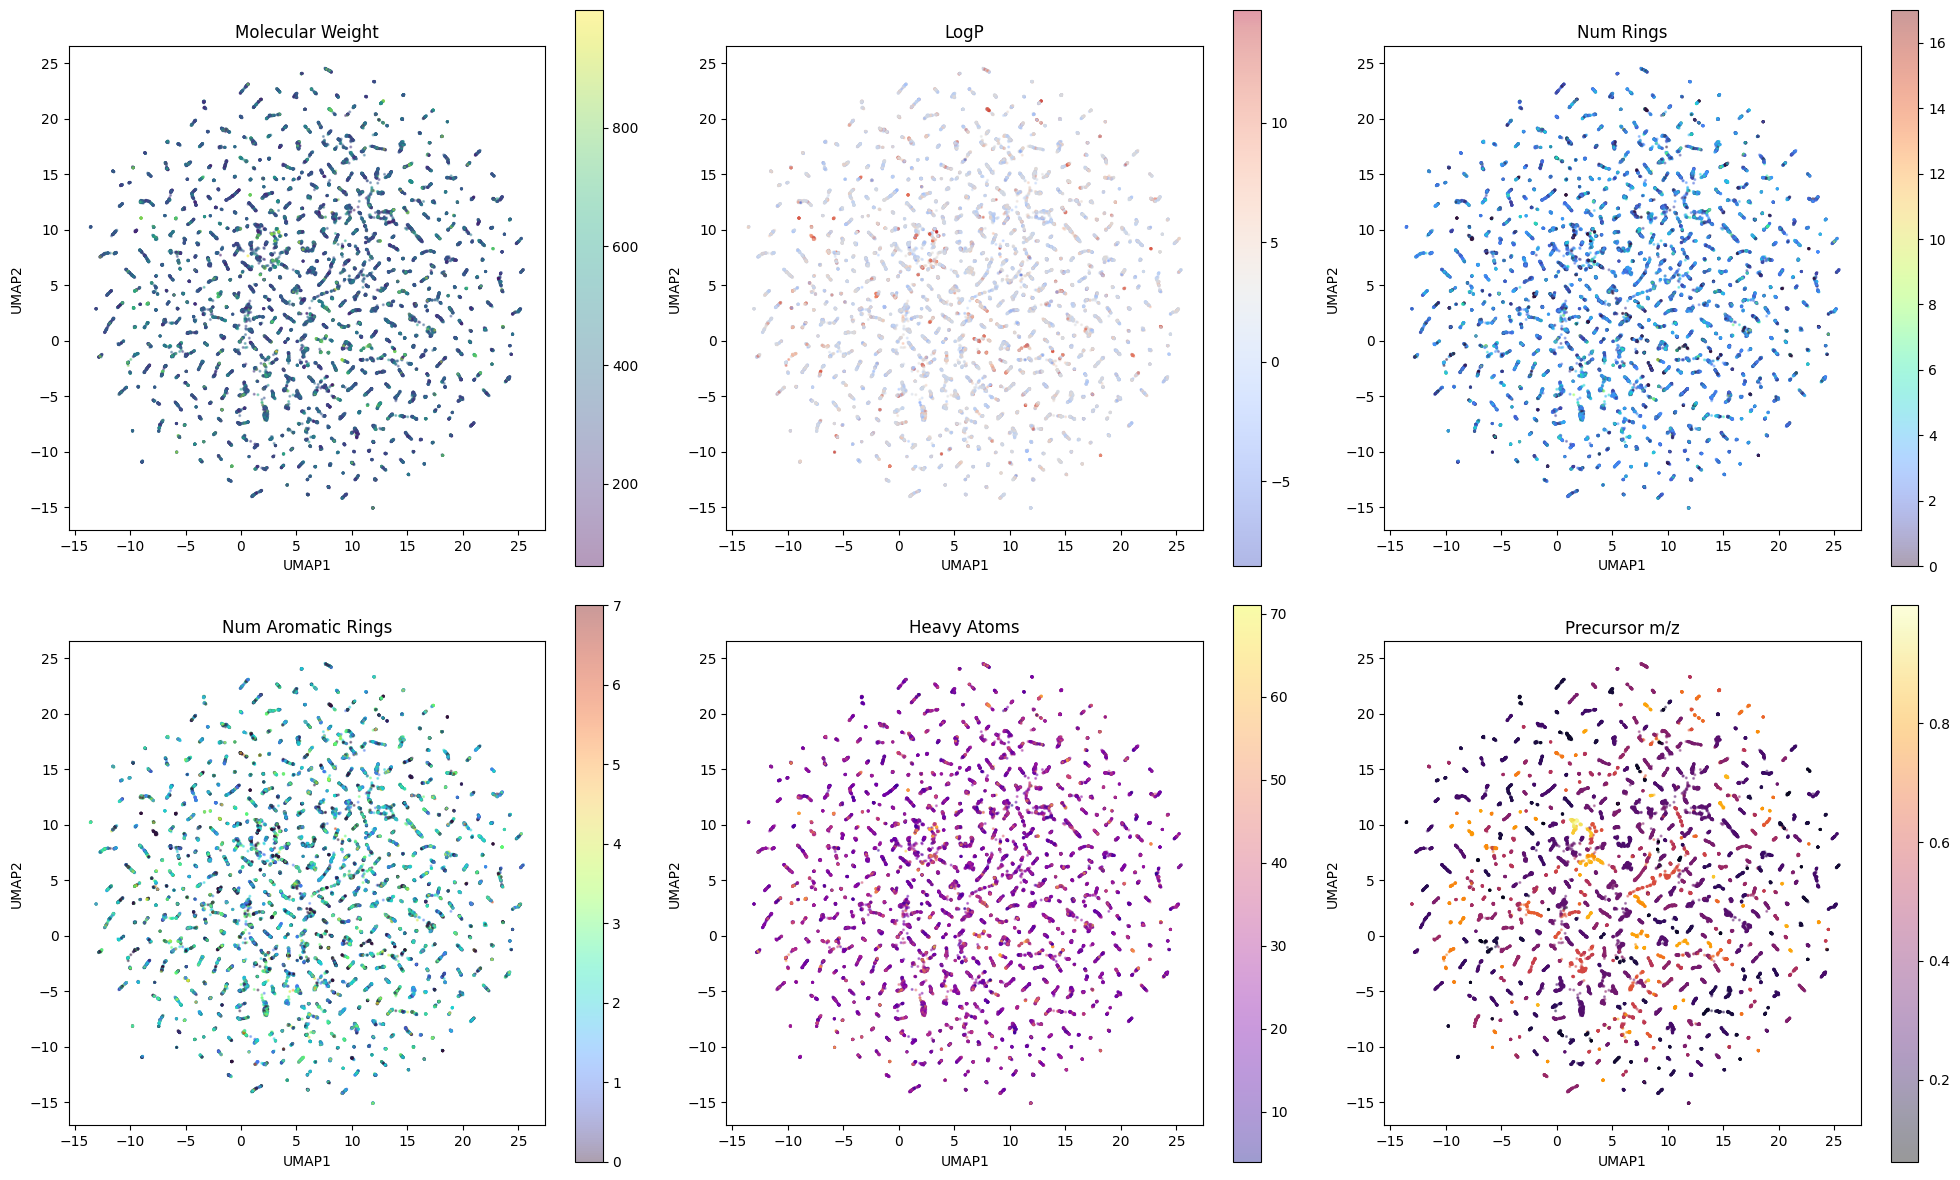

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

props = [
    ("Molecular Weight", mol_weight[umap_idx], "viridis"),
    ("LogP", logp[umap_idx], "coolwarm"),
    ("Num Rings", num_rings[umap_idx].astype(float), "turbo"),
    ("Num Aromatic Rings", num_aromatic_rings[umap_idx].astype(float), "turbo"),
    ("Heavy Atoms", num_heavy_atoms[umap_idx].astype(float), "plasma"),
    ("Precursor m/z", all_meta["precursor_mz"][umap_idx], "inferno"),
]

for ax, (title, values, cmap) in zip(axes.flat, props):
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=values, cmap=cmap, s=1.5, alpha=0.4, rasterized=True)
    ax.set_title(title)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_aspect("equal")
    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()

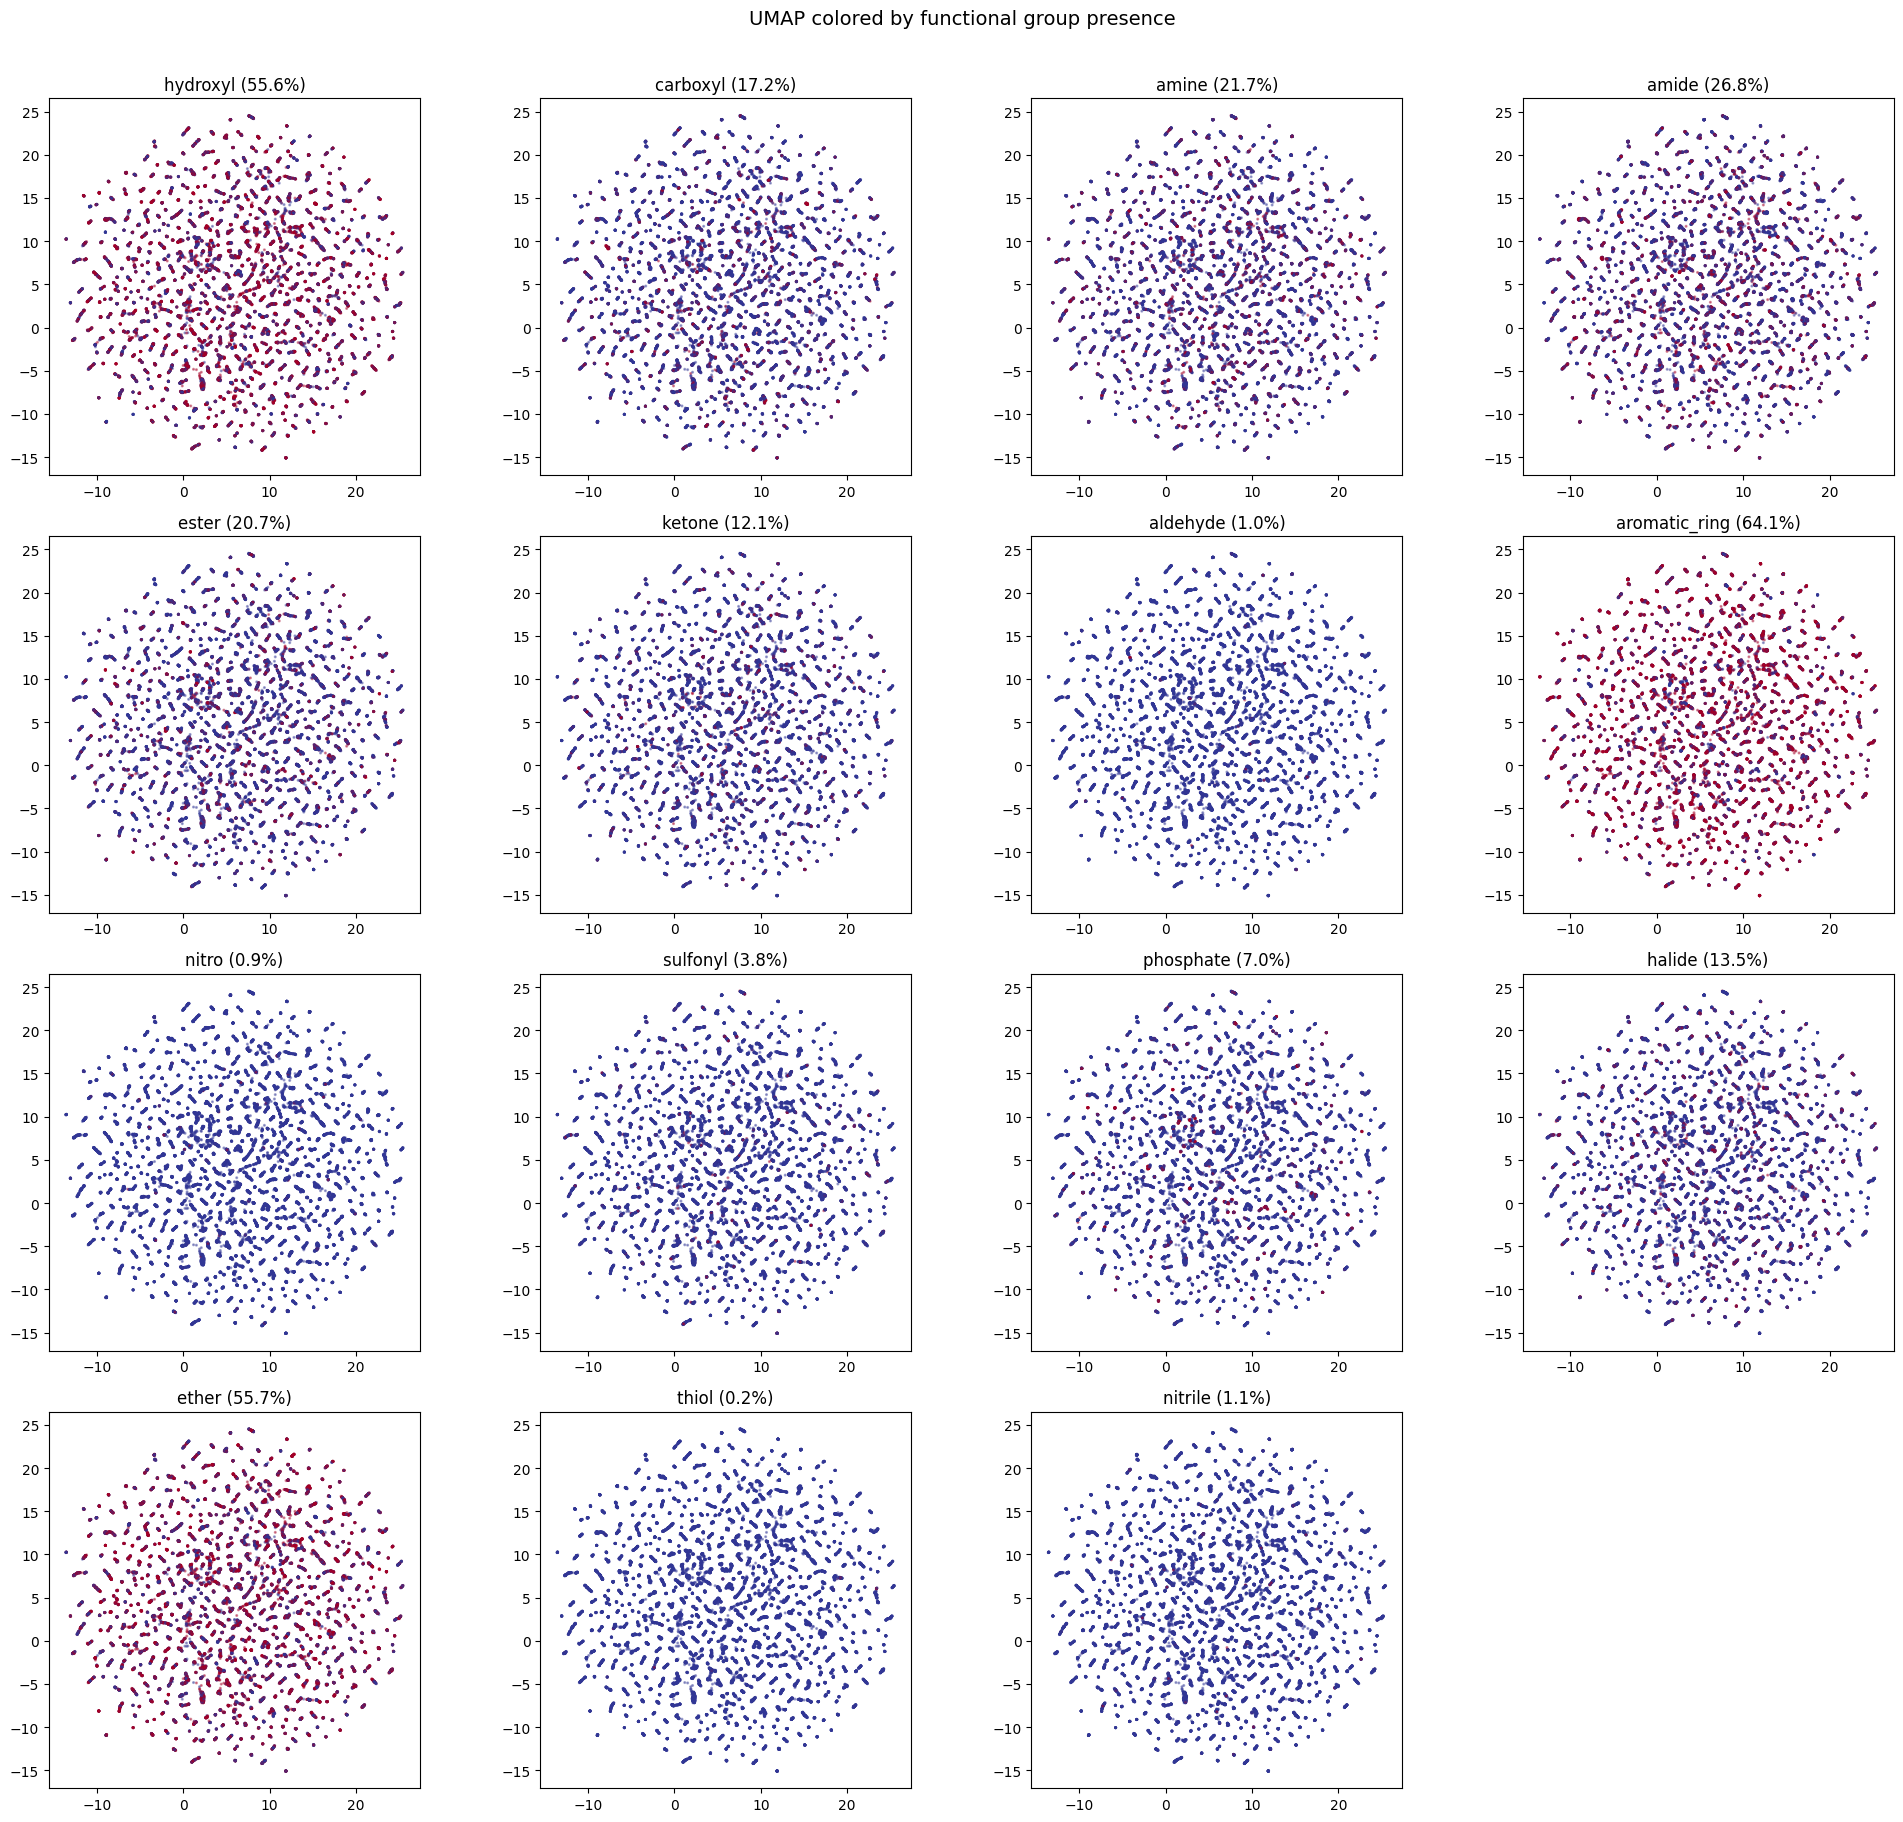

In [12]:
# UMAP colored by functional group presence
fg_names = list(FG_SMARTS.keys())
n_fgs = len(fg_names)
ncols = 4
nrows = (n_fgs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = axes.flat

for i, name in enumerate(fg_names):
    has_fg = (fg_counts[name][umap_idx] > 0).astype(float)
    prevalence = has_fg.mean()
    sc = axes[i].scatter(
        coords[:, 0], coords[:, 1],
        c=has_fg, cmap="RdYlBu_r", s=1.5, alpha=0.4, rasterized=True, vmin=0, vmax=1,
    )
    axes[i].set_title(f"{name} ({prevalence:.1%})")
    axes[i].set_aspect("equal")

# Hide unused axes
for j in range(i + 1, len(list(axes))):
    axes[j].set_visible(False)

plt.suptitle("UMAP colored by functional group presence", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Linear Probes: Fingerprint & Molecular Property Prediction

In [13]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score

# Use valid molecules only, subsample for speed
probe_size = min(50_000, valid_idx.shape[0])
probe_idx = rng.choice(valid_idx, size=probe_size, replace=False)
X_probe = all_embeds[probe_idx]

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# 6a. Predict molecular weight from embeddings
print("=== Ridge: Molecular Weight ===")
ridge_mw = Ridge(alpha=1.0)
scores_mw = cross_val_score(ridge_mw, X_probe, mol_weight[probe_idx], cv=cv, scoring="r2", n_jobs=-1)
print(f"  R^2: {scores_mw.mean():.4f} +/- {scores_mw.std():.4f}")

# 6b. Predict LogP
print("\n=== Ridge: LogP ===")
ridge_logp = Ridge(alpha=1.0)
scores_logp = cross_val_score(ridge_logp, X_probe, logp[probe_idx], cv=cv, scoring="r2", n_jobs=-1)
print(f"  R^2: {scores_logp.mean():.4f} +/- {scores_logp.std():.4f}")

# 6c. Predict num heavy atoms
print("\n=== Ridge: Num Heavy Atoms ===")
ridge_ha = Ridge(alpha=1.0)
scores_ha = cross_val_score(ridge_ha, X_probe, num_heavy_atoms[probe_idx].astype(float), cv=cv, scoring="r2", n_jobs=-1)
print(f"  R^2: {scores_ha.mean():.4f} +/- {scores_ha.std():.4f}")

# 6d. Predict num rings
print("\n=== Ridge: Num Rings ===")
ridge_rings = Ridge(alpha=1.0)
scores_rings = cross_val_score(ridge_rings, X_probe, num_rings[probe_idx].astype(float), cv=cv, scoring="r2", n_jobs=-1)
print(f"  R^2: {scores_rings.mean():.4f} +/- {scores_rings.std():.4f}")

# 6e. Predict top functional groups (binary classification)
print("\n=== Logistic Regression: Functional Group Prediction ===")
for name in fg_names:
    y = (fg_counts[name][probe_idx] > 0).astype(int)
    pos_frac = y.mean()
    if pos_frac < 0.01 or pos_frac > 0.99:
        print(f"  {name:20s}: skipped (prevalence={pos_frac:.3f})")
        continue
    clf = LogisticRegression(max_iter=500, C=1.0, solver="lbfgs", n_jobs=-1)
    scores = cross_val_score(clf, X_probe, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"  {name:20s}: AUC={scores.mean():.4f} +/- {scores.std():.4f}  (prevalence={pos_frac:.3f})")

=== Ridge: Molecular Weight ===


  R^2: 0.0359 +/- 0.0027

=== Ridge: LogP ===


  R^2: 0.0449 +/- 0.0025

=== Ridge: Num Heavy Atoms ===


  R^2: 0.0354 +/- 0.0026

=== Ridge: Num Rings ===


  R^2: 0.0115 +/- 0.0033

=== Logistic Regression: Functional Group Prediction ===


...

  sulfonyl            : AUC=0.5443 +/- 0.0126  (prevalence=0.038)


  phosphate           : AUC=0.6448 +/- 0.0052  (prevalence=0.074)


  halide              : AUC=0.5492 +/- 0.0132  (prevalence=0.133)


  ether               : AUC=0.5251 +/- 0.0044  (prevalence=0.558)
  thiol               : skipped (prevalence=0.002)


  nitrile             : AUC=0.5529 +/- 0.0104  (prevalence=0.011)


## 7. MACCS Key Enrichment in Embedding Neighborhoods

In [14]:
# For each MACCS key, measure whether embedding k-NN share the same bit more than random
# Use the subsample from section 4
sub_maccs = maccs_fps[sub_idx]
k = 10

# Global prevalence of each MACCS key
global_prev = sub_maccs.mean(axis=0)  # (167,)

# For each query, measure fraction of k-NN that share each MACCS bit
nn_maccs = sub_maccs[knn_embed_idx[:, :k]]  # (N, k, 167)
query_maccs = sub_maccs[:, np.newaxis, :]  # (N, 1, 167)
# Agreement: both have the bit set
nn_agreement = ((nn_maccs == 1) & (query_maccs == 1)).mean(axis=1)  # (N, 167)
# Expected agreement if random: P(query=1) * P(neighbor=1) = prevalence^2
# But we condition on query having the bit, so expected = prevalence for that bit

# For molecules WITH the bit set: what fraction of their k-NN also have it?
enrichment = []
for bit in range(167):
    if global_prev[bit] < 0.05 or global_prev[bit] > 0.95:
        continue  # skip very rare or ubiquitous bits
    has_bit = sub_maccs[:, bit] == 1
    if has_bit.sum() < 100:
        continue
    nn_has_bit = nn_maccs[has_bit, :, bit]  # (N_with_bit, k)
    observed_rate = nn_has_bit.mean()
    expected_rate = global_prev[bit]
    lift = observed_rate / expected_rate
    enrichment.append((bit, observed_rate, expected_rate, lift))

enrichment.sort(key=lambda x: -x[3])

print(f"MACCS key enrichment in embedding k={k} NN (top 20 by lift):")
print(f"{'bit':>5s}  {'observed':>10s}  {'expected':>10s}  {'lift':>8s}")
for bit, obs, exp, lift in enrichment[:20]:
    print(f"{bit:5d}  {obs:10.4f}  {exp:10.4f}  {lift:8.2f}x")

print(f"\nBottom 10 by lift (least enriched):")
for bit, obs, exp, lift in enrichment[-10:]:
    print(f"{bit:5d}  {obs:10.4f}  {exp:10.4f}  {lift:8.2f}x")

lifts = [x[3] for x in enrichment]
print(f"\nMean lift across {len(enrichment)} MACCS keys: {np.mean(lifts):.3f}")
print(f"Median lift: {np.median(lifts):.3f}")
print(f"Lift > 1.5: {sum(1 for l in lifts if l > 1.5)} / {len(lifts)}")
print(f"Lift > 2.0: {sum(1 for l in lifts if l > 2.0)} / {len(lifts)}")

MACCS key enrichment in embedding k=10 NN (top 20 by lift):
  bit    observed    expected      lift
   30      0.2764      0.0571      4.84x
   29      0.2993      0.0778      3.85x
   49      0.2569      0.0694      3.70x
   48      0.2973      0.0812      3.66x
   59      0.1288      0.0529      2.44x
   67      0.1235      0.0522      2.36x
   64      0.1182      0.0507      2.33x
   37      0.1240      0.0532      2.33x
   73      0.1179      0.0517      2.28x
   52      0.1170      0.0538      2.17x
   19      0.1077      0.0537      2.01x
   26      0.1230      0.0630      1.95x
  130      0.2765      0.1421      1.95x
   69      0.1287      0.0680      1.89x
  102      0.2825      0.1514      1.87x
  103      0.1529      0.0857      1.78x
   81      0.1616      0.0932      1.73x
   94      0.1836      0.1098      1.67x
  114      0.3216      0.1998      1.61x
   87      0.1836      0.1170      1.57x

Bottom 10 by lift (least enriched):
  152      0.7093      0.6815      1.04x
  

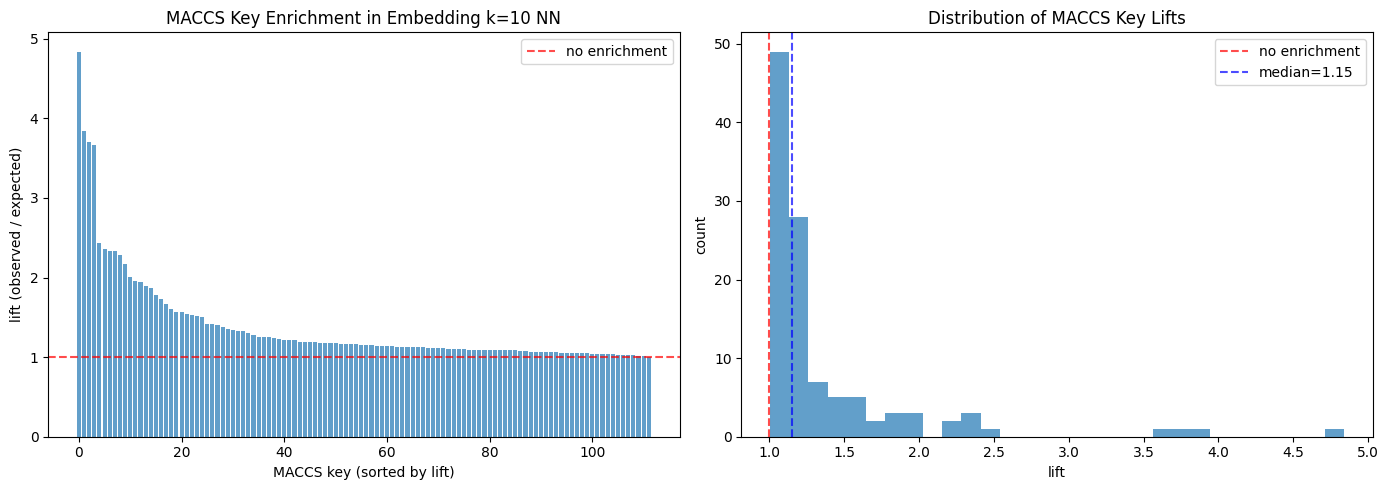

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(lifts)), sorted(lifts, reverse=True), edgecolor="none", alpha=0.7)
axes[0].axhline(1.0, color="red", linestyle="--", alpha=0.7, label="no enrichment")
axes[0].set_xlabel("MACCS key (sorted by lift)")
axes[0].set_ylabel("lift (observed / expected)")
axes[0].set_title(f"MACCS Key Enrichment in Embedding k={k} NN")
axes[0].legend()

axes[1].hist(lifts, bins=30, edgecolor="none", alpha=0.7)
axes[1].axvline(1.0, color="red", linestyle="--", alpha=0.7, label="no enrichment")
axes[1].axvline(np.median(lifts), color="blue", linestyle="--", alpha=0.7, label=f"median={np.median(lifts):.2f}")
axes[1].set_xlabel("lift")
axes[1].set_ylabel("count")
axes[1].set_title("Distribution of MACCS Key Lifts")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Summary

Key metrics to compare across checkpoints:

| Metric | Interpretation |
|--------|---------------|
| Pearson(cosine, Tanimoto) | How well embedding proximity tracks molecular similarity |
| Embed kNN Tanimoto vs FP kNN Tanimoto | How close embedding retrieval is to structural oracle |
| Linear probe R^2 (MW, LogP, heavy atoms) | Whether molecular properties are linearly decodable |
| Functional group AUC | Whether substructure presence is encoded |
| MACCS enrichment lift | Whether embedding neighbors share substructures |